# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan

- Nama: Sutriadi Kurniawan
- Email: sutriadik@gmail.com
- Id Dicoding: sutriadi_kurniawan

## Persiapan

### Menyiapkan library yang dibutuhkan

Mengimpor seluruh library yang diperlukan untuk analisis data, visualisasi, dan pemodelan machine learning.

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
import joblib, os

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (12, 6), 'font.size': 11,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold'})
np.random.seed(42)
print('Semua library berhasil diimport!')

Semua library berhasil diimport!


### Menyiapkan data yang akan digunakan

Dataset berisi informasi performa akademik dan demografis siswa Jaya Jaya Institut.
Data dibaca dari file `data.csv` dengan delimiter titik koma (`;`).

In [107]:
df = pd.read_csv('data.csv', delimiter=';')
print(f'Jumlah baris  : {df.shape[0]:,}')
print(f'Jumlah kolom  : {df.shape[1]}')
df.head()

Jumlah baris  : 4,424
Jumlah kolom  : 37


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

Pada tahap ini kita mengeksplorasi struktur dataset, distribusi target,
dan pola-pola penting yang memandu proses analisis dan pemodelan.

### Informasi Umum Dataset

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

Dataset terdiri dari **4.424 baris dan 37 kolom**. Seluruh fitur bertipe numerik kecuali kolom `Status` yang merupakan target kategorikal.

In [109]:
df.describe().round(2)

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,...,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00
mean,1.18,18.67,1.73,8856.64,0.89,4.58,132.61,1.87,19.56,22.28,...,0.14,0.54,6.23,8.06,4.44,10.23,0.15,11.57,1.23,0.00
std,0.61,17.48,1.31,2063.57,0.31,10.22,13.19,6.91,15.60,15.34,...,0.69,1.92,2.20,3.95,3.01,5.21,0.75,2.66,1.38,2.27
min,1.00,1.00,0.00,33.00,0.00,1.00,95.00,1.00,1.00,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7.60,-0.80,-4.06
25%,1.00,1.00,1.00,9085.00,1.00,1.00,125.00,1.00,2.00,3.00,...,0.00,0.00,5.00,6.00,2.00,10.75,0.00,9.40,0.30,-1.70
50%,1.00,17.00,1.00,9238.00,1.00,1.00,133.10,1.00,19.00,19.00,...,0.00,0.00,6.00,8.00,5.00,12.20,0.00,11.10,1.40,0.32
75%,1.00,39.00,2.00,9556.00,1.00,1.00,140.00,1.00,37.00,37.00,...,0.00,0.00,7.00,10.00,6.00,13.33,0.00,13.90,2.60,1.79
max,6.00,57.00,9.00,9991.00,1.00,43.00,190.00,109.00,44.00,44.00,...,12.00,19.00,23.00,33.00,20.00,18.57,12.00,16.20,3.70,3.51


In [110]:
print('=== Kualitas Data ===')
print(f'Missing values : {df.isnull().sum().sum()}')
print(f'Duplikat       : {df.duplicated().sum()}')
print()
print('=== Distribusi Target (Status) ===')
vc  = df['Status'].value_counts()
vcp = df['Status'].value_counts(normalize=True) * 100
for s in vc.index:
    print(f'  {s:<12}: {vc[s]:>4,}  ({vcp[s]:.1f}%)')

=== Kualitas Data ===
Missing values : 0
Duplikat       : 0

=== Distribusi Target (Status) ===
  Graduate    : 2,209  (49.9%)
  Dropout     : 1,421  (32.1%)
  Enrolled    :  794  (17.9%)


**Insight:** Dataset bersih — tidak ada missing values atau duplikat.
Distribusi target: **Graduate 49.9%**, **Dropout 32.1%**, **Enrolled 17.9%**.
Dropout rate 32.1% menunjukkan hampir sepertiga siswa tidak menyelesaikan pendidikannya — angka yang signifikan dan perlu ditangani.

### Visualisasi 1: Distribusi Status Siswa

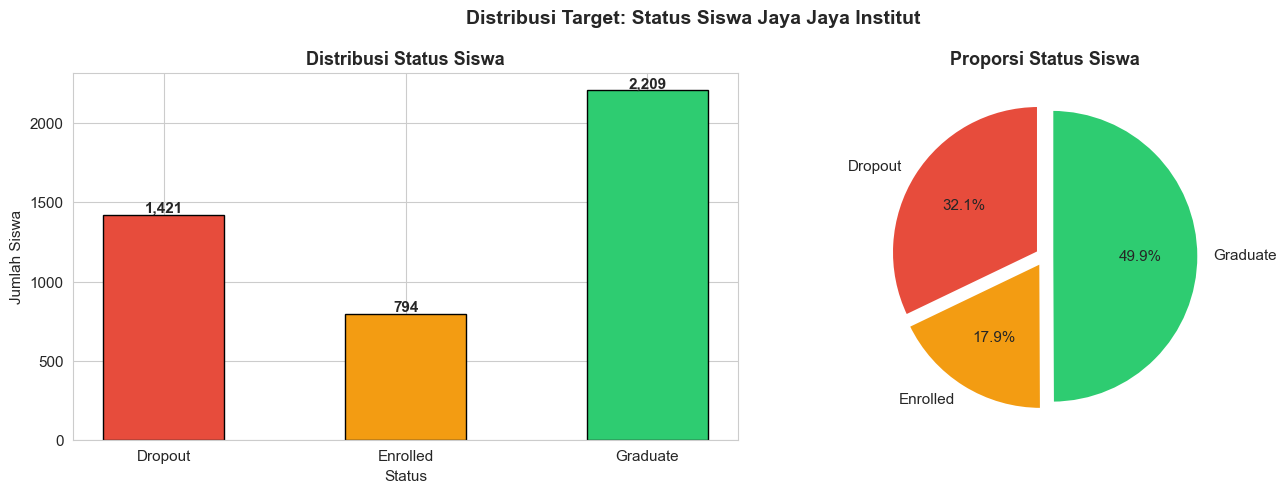

In [111]:
order  = ['Dropout', 'Enrolled', 'Graduate']
colors = ['#e74c3c', '#f39c12', '#2ecc71']
tc     = df['Status'].value_counts().reindex(order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bars = axes[0].bar(tc.index, tc.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Distribusi Status Siswa')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Jumlah Siswa')
for bar, val in zip(bars, tc.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+15,
                 f'{val:,}', ha='center', fontweight='bold')

axes[1].pie(tc.values, labels=tc.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=[0.05]*3,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Proporsi Status Siswa')

plt.suptitle('Distribusi Target: Status Siswa Jaya Jaya Institut',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** Dari 4.424 siswa, **1.421 (32.1%) dropout**. Angka ini jauh di atas toleransi wajar (<10%),
menandakan perlunya sistem deteksi dini yang kuat.
Siswa Enrolled (17.9%) belum memiliki label akhir sehingga tidak digunakan dalam training model.

### Visualisasi 2: Performa Akademik per Status

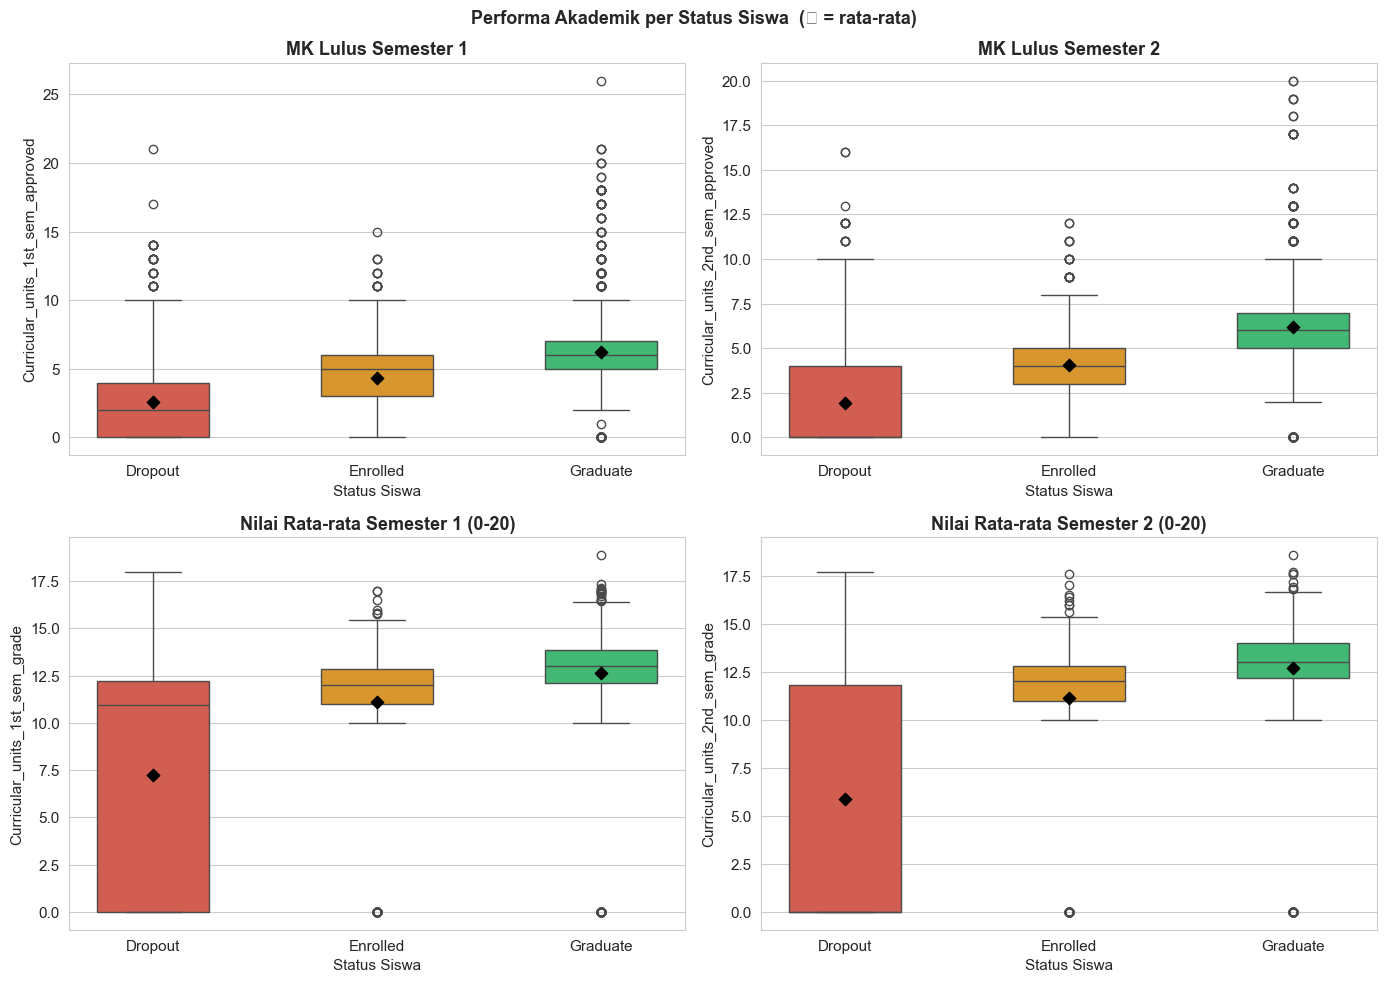

In [112]:
palette = {'Dropout':'#e74c3c','Enrolled':'#f39c12','Graduate':'#2ecc71'}
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
academic_vars = [
    ('Curricular_units_1st_sem_approved', 'MK Lulus Semester 1'),
    ('Curricular_units_2nd_sem_approved', 'MK Lulus Semester 2'),
    ('Curricular_units_1st_sem_grade',    'Nilai Rata-rata Semester 1 (0-20)'),
    ('Curricular_units_2nd_sem_grade',    'Nilai Rata-rata Semester 2 (0-20)'),
]
for ax, (col, title) in zip(axes.flatten(), academic_vars):
    sns.boxplot(data=df, x='Status', y=col, order=order,
                palette=palette, ax=ax, width=0.5)
    means = df.groupby('Status')[col].mean().reindex(order)
    for i, mean in enumerate(means):
        ax.scatter(i, mean, marker='D', color='black', s=40, zorder=5)
    ax.set_title(title)
    ax.set_xlabel('Status Siswa')

plt.suptitle('Performa Akademik per Status Siswa  (◆ = rata-rata)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** Perbedaan sangat signifikan antara Dropout dan Graduate:
- Siswa **Dropout** rata-rata lulus 0–2 MK per semester; **Graduate** lulus 5–6 MK.
- Nilai rata-rata **Dropout** mendekati 0 (banyak tidak mengikuti ujian); **Graduate** berkisar 12–14.
- Performa akademik semester awal adalah **prediktor terkuat dropout**.

### Visualisasi 3: Faktor Finansial vs Status

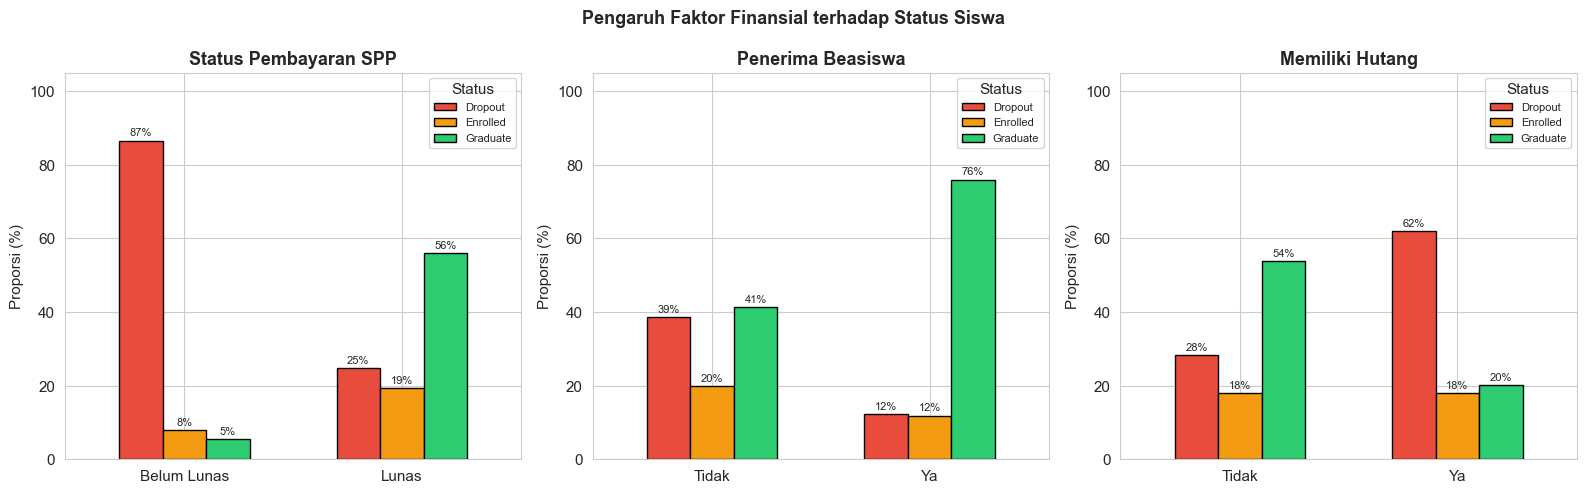

In [113]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fin_vars = [
    ('Tuition_fees_up_to_date', ['Belum Lunas','Lunas'], 'Status Pembayaran SPP'),
    ('Scholarship_holder',      ['Tidak','Ya'],          'Penerima Beasiswa'),
    ('Debtor',                  ['Tidak','Ya'],          'Memiliki Hutang'),
]
for ax, (col, labels, title) in zip(axes, fin_vars):
    ct = pd.crosstab(df[col], df['Status'], normalize='index')[order] * 100
    ct.index = labels
    ct.plot(kind='bar', ax=ax, color=colors, edgecolor='black', width=0.6)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Proporsi (%)')
    ax.set_xticklabels(labels, rotation=0)
    ax.legend(title='Status', fontsize=8)
    ax.set_ylim(0, 105)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f%%', fontsize=8, padding=2)

plt.suptitle('Pengaruh Faktor Finansial terhadap Status Siswa',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:**
- Siswa dengan **SPP belum lunas**: ~70% dropout, hanya ~8% graduate.
- **Penerima beasiswa**: proporsi graduate jauh lebih tinggi.
- **Memiliki hutang**: dropout rate jauh lebih tinggi.
- Faktor keuangan berkorelasi kuat dengan risiko dropout.

### Visualisasi 4: Faktor Demografis vs Status

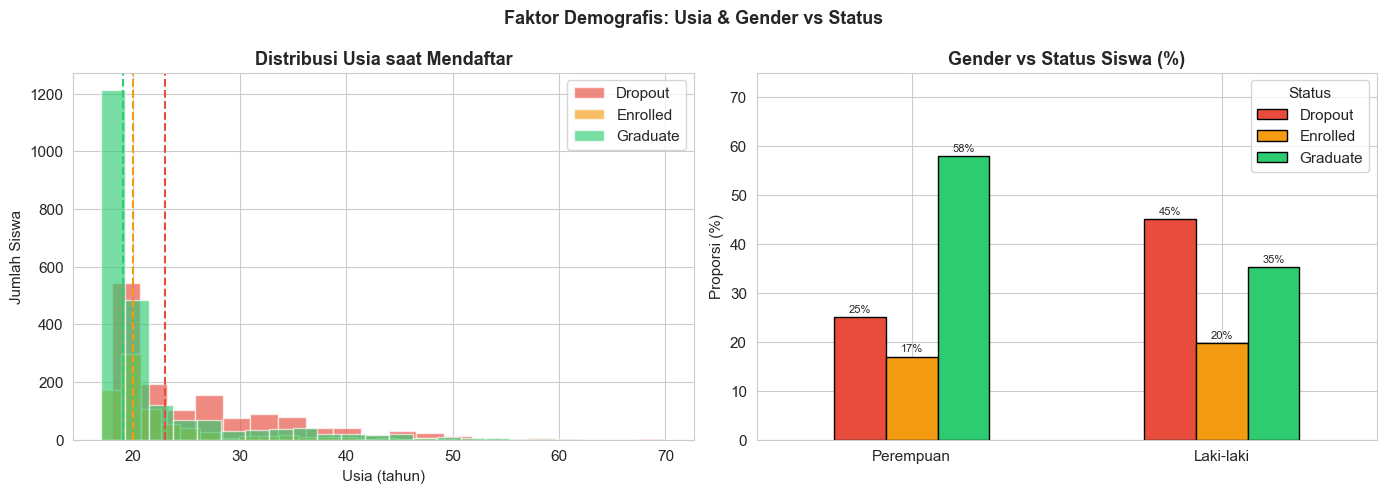

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for status, clr in zip(order, colors):
    sub = df[df['Status'] == status]['Age_at_enrollment']
    axes[0].hist(sub, bins=20, alpha=0.65, color=clr, label=status, edgecolor='white')
    axes[0].axvline(sub.median(), color=clr, linestyle='--', lw=1.5)
axes[0].set_title('Distribusi Usia saat Mendaftar')
axes[0].set_xlabel('Usia (tahun)')
axes[0].set_ylabel('Jumlah Siswa')
axes[0].legend()

ct_gender = pd.crosstab(df['Gender'], df['Status'], normalize='index')[order] * 100
ct_gender.index = ['Perempuan', 'Laki-laki']
ct_gender.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black', width=0.5)
axes[1].set_title('Gender vs Status Siswa (%)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Proporsi (%)')
axes[1].set_xticklabels(['Perempuan', 'Laki-laki'], rotation=0)
axes[1].legend(title='Status')
axes[1].set_ylim(0, 75)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.0f%%', fontsize=8, padding=2)

plt.suptitle('Faktor Demografis: Usia & Gender vs Status',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:**
- Distribusi usia Dropout lebih tersebar ke kanan (usia lebih tua) dibanding Graduate.
- Siswa **laki-laki** memiliki proporsi dropout (~45%) lebih tinggi dari perempuan (~25%).

### Visualisasi 5: Dropout Rate per Kelompok Usia

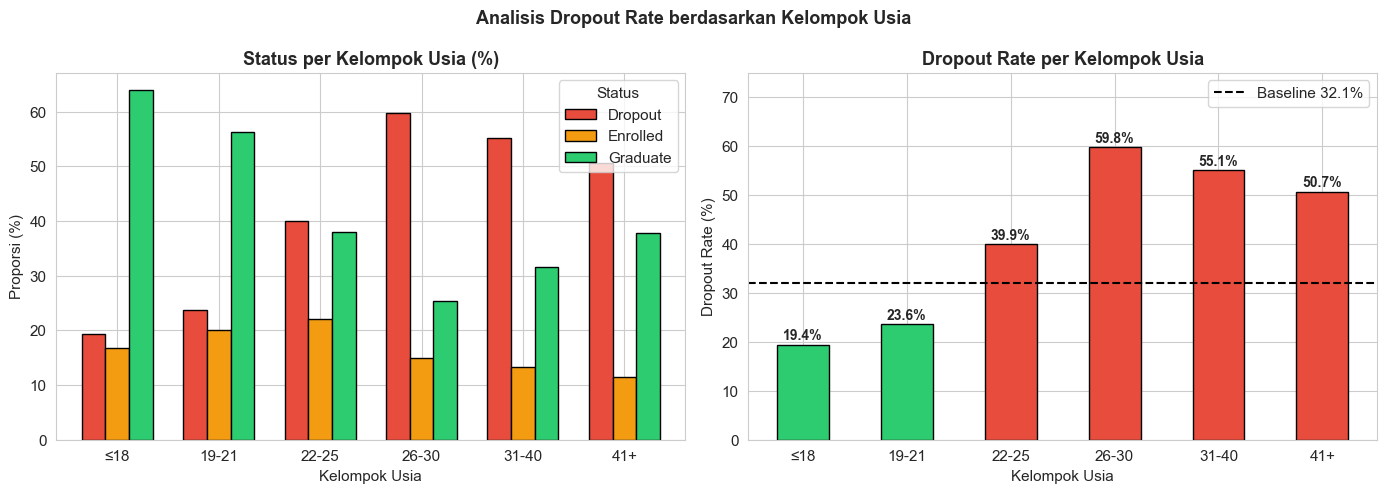

In [115]:
df['AgeGroup'] = pd.cut(df['Age_at_enrollment'],
                         bins=[0,18,21,25,30,40,100],
                         labels=['≤18','19-21','22-25','26-30','31-40','41+'])

age_stat = (df.groupby('AgeGroup', observed=True)['Status']
            .value_counts(normalize=True).unstack().fillna(0) * 100)
age_stat = age_stat.reindex(columns=order, fill_value=0)

baseline_dr = df['Status'].eq('Dropout').mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

age_stat.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', width=0.7)
axes[0].set_title('Status per Kelompok Usia (%)')
axes[0].set_xlabel('Kelompok Usia')
axes[0].set_ylabel('Proporsi (%)')
axes[0].set_xticklabels(age_stat.index, rotation=0)
axes[0].legend(title='Status')

dr_age    = age_stat['Dropout']
bar_clrs  = ['#e74c3c' if v > baseline_dr else '#2ecc71' for v in dr_age]
bars      = axes[1].bar(dr_age.index, dr_age.values, color=bar_clrs,
                        edgecolor='black', width=0.5)
axes[1].axhline(baseline_dr, color='black', linestyle='--', lw=1.5,
                label=f'Baseline {baseline_dr:.1f}%')
axes[1].set_title('Dropout Rate per Kelompok Usia')
axes[1].set_xlabel('Kelompok Usia')
axes[1].set_ylabel('Dropout Rate (%)')
axes[1].set_ylim(0, 75)
for bar, val in zip(bars, dr_age.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
axes[1].legend()

plt.suptitle('Analisis Dropout Rate berdasarkan Kelompok Usia',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** Siswa yang mendaftar di usia **26–30** dan **41+** memiliki dropout rate tertinggi,
jauh melampaui baseline. Bar merah = di atas baseline, hijau = di bawah baseline.

### Visualisasi 6: Korelasi Fitur Numerik dengan Dropout

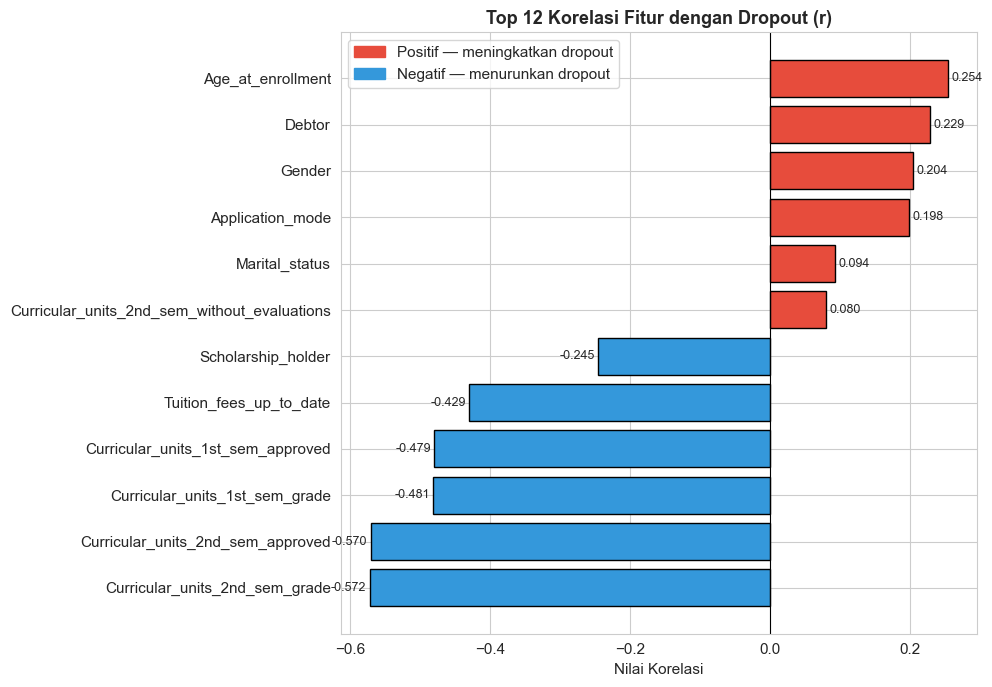

In [116]:
df_corr = df.copy()
df_corr['Dropout_flag'] = (df_corr['Status'] == 'Dropout').astype(int)
num_cols  = df_corr.select_dtypes(include='number').columns.tolist()
corr_val  = df_corr[num_cols].corr()['Dropout_flag'].drop('Dropout_flag').sort_values()

top_corr = pd.concat([corr_val.head(6), corr_val.tail(6)])
clrs_top = ['#e74c3c' if v > 0 else '#3498db' for v in top_corr.values]

plt.figure(figsize=(10, 7))
bars = plt.barh(top_corr.index, top_corr.values, color=clrs_top, edgecolor='black')
plt.axvline(0, color='black', lw=0.8)
for bar, val in zip(bars, top_corr.values):
    plt.text(val + (0.005 if val >= 0 else -0.005), bar.get_y()+bar.get_height()/2,
             f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
red_p  = mpatches.Patch(color='#e74c3c', label='Positif — meningkatkan dropout')
blue_p = mpatches.Patch(color='#3498db', label='Negatif — menurunkan dropout')
plt.legend(handles=[red_p, blue_p])
plt.title('Top 12 Korelasi Fitur dengan Dropout (r)', fontweight='bold')
plt.xlabel('Nilai Korelasi')
plt.tight_layout()
plt.show()

**Insight:**
- **Korelasi negatif terkuat** (melindungi dari dropout): MK lulus dan SPP lancar — semakin banyak MK lulus dan SPP lancar, semakin kecil risiko dropout.
- **Korelasi positif terkuat** (meningkatkan dropout): usia saat mendaftar dan status debitur.

## Data Preparation / Preprocessing

Tahap persiapan data sebelum training model:
1. **Filter** — hanya Dropout & Graduate (siswa Enrolled dikecualikan)
2. **Feature Engineering** — membuat 7 fitur turunan
3. **Feature Selection** — memilih top 15 fitur paling informatif via RF importance
4. **Train-Test Split** — 80% training, 20% testing
5. **Standarisasi** — StandardScaler

### Step 1: Filter Data — Dropout vs Graduate

Model hanya dilatih menggunakan siswa **Dropout** dan **Graduate**.
Siswa **Enrolled** dikecualikan karena belum memiliki label akhir —
memasukkannya akan membuat target tidak jelas dan menurunkan validitas model.

> Data Enrolled dapat digunakan pada tahap **inferensi** untuk memprediksi kemungkinan
status akhir siswa yang masih aktif kuliah.

In [117]:
df_model = df[df['Status'].isin(['Dropout', 'Graduate'])].copy()

print(f'Total data keseluruhan      : {len(df):,}')
print(f'Enrolled (dikeluarkan)      : {(df["Status"]=="Enrolled").sum():,}')
print(f'Data untuk modeling         : {len(df_model):,}')
print()
print('Distribusi kelas untuk modeling:')
vc = df_model['Status'].value_counts()
for s in vc.index:
    print(f'  {s:<12}: {vc[s]:>4,}  ({vc[s]/len(df_model)*100:.1f}%)')

Total data keseluruhan      : 4,424
Enrolled (dikeluarkan)      : 794
Data untuk modeling         : 3,630

Distribusi kelas untuk modeling:
  Graduate    : 2,209  (60.9%)
  Dropout     : 1,421  (39.1%)


**Catatan:** Setelah filter, dataset menjadi **3.630 baris**:
- Dropout : 1.421 (39.1%)
- Graduate: 2.209 (60.9%)

Terdapat ketidakseimbangan kelas yang wajar dan akan diatasi dengan `class_weight='balanced'`.

### Step 2: Feature Engineering

In [118]:
df_model['Sem1_approval_rate'] = (
    df_model['Curricular_units_1st_sem_approved'] /
    df_model['Curricular_units_1st_sem_enrolled'].replace(0, 1)
)
df_model['Sem2_approval_rate'] = (
    df_model['Curricular_units_2nd_sem_approved'] /
    df_model['Curricular_units_2nd_sem_enrolled'].replace(0, 1)
)
df_model['Total_approved']     = (
    df_model['Curricular_units_1st_sem_approved'] +
    df_model['Curricular_units_2nd_sem_approved']
)
df_model['Avg_grade']          = (
    df_model['Curricular_units_1st_sem_grade'] +
    df_model['Curricular_units_2nd_sem_grade']
) / 2
df_model['Grade_diff']         = (
    df_model['Curricular_units_2nd_sem_grade'] -
    df_model['Curricular_units_1st_sem_grade']
)
df_model['Total_evaluations']  = (
    df_model['Curricular_units_1st_sem_evaluations'] +
    df_model['Curricular_units_2nd_sem_evaluations']
)
df_model['Total_without_eval'] = (
    df_model['Curricular_units_1st_sem_without_evaluations'] +
    df_model['Curricular_units_2nd_sem_without_evaluations']
)

print('7 fitur turunan berhasil dibuat:')
new_feats = ['Sem1_approval_rate','Sem2_approval_rate','Total_approved',
             'Avg_grade','Grade_diff','Total_evaluations','Total_without_eval']
for f in new_feats:
    print(f'  + {f}')

7 fitur turunan berhasil dibuat:
  + Sem1_approval_rate
  + Sem2_approval_rate
  + Total_approved
  + Avg_grade
  + Grade_diff
  + Total_evaluations
  + Total_without_eval


### Step 3: Feature Selection (Top 15)

In [119]:
# Encode target: 0 = Dropout, 1 = Graduate
le_target = LabelEncoder()
df_model['Status_encoded'] = le_target.fit_transform(df_model['Status'])

print('Encoding target:')
for i, cls in enumerate(le_target.classes_):
    print(f'  {i} = {cls}')

drop_cols = ['Status', 'Status_encoded', 'AgeGroup']
X_all = df_model.drop(columns=[c for c in drop_cols if c in df_model.columns])
y     = df_model['Status_encoded']

# Hitung feature importance
rf_init = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_init.fit(X_all, y)

feat_imp = pd.DataFrame({
    'Feature':    X_all.columns,
    'Importance': rf_init.feature_importances_
}).sort_values('Importance', ascending=False)

selected_features = list(feat_imp.head(15)['Feature'])

print(f'\nTop 15 fitur terpilih (dari {X_all.shape[1]} total):')
for i, (_, row) in enumerate(feat_imp.head(15).iterrows(), 1):
    print(f'  {i:2d}. {row["Feature"]:<50} {row["Importance"]:.4f}')

Encoding target:
  0 = Dropout
  1 = Graduate

Top 15 fitur terpilih (dari 43 total):
   1. Sem2_approval_rate                                 0.1348
   2. Sem1_approval_rate                                 0.1172
   3. Total_approved                                     0.1142
   4. Curricular_units_2nd_sem_approved                  0.0943
   5. Avg_grade                                          0.0530
   6. Curricular_units_2nd_sem_grade                     0.0498
   7. Curricular_units_1st_sem_approved                  0.0496
   8. Tuition_fees_up_to_date                            0.0341
   9. Curricular_units_1st_sem_grade                     0.0339
  10. Admission_grade                                    0.0216
  11. Course                                             0.0206
  12. Previous_qualification_grade                       0.0189
  13. Total_evaluations                                  0.0183
  14. Grade_diff                                         0.0180
  15. Age_at_enrol

### Step 4 & 5: Train-Test Split & Standarisasi

In [120]:
X = X_all[selected_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training set : {X_train.shape[0]:,} sampel')
print(f'Testing set  : {X_test.shape[0]:,} sampel')
print(f'Jumlah fitur : {len(selected_features)}')
print(f'\nDistribusi kelas di training set:')
vc_tr = pd.Series(y_train).value_counts()
for k, v in vc_tr.items():
    print(f'  {le_target.classes_[k]:<12}: {v:,} ({v/len(y_train)*100:.1f}%)')

Training set : 2,904 sampel
Testing set  : 726 sampel
Jumlah fitur : 15

Distribusi kelas di training set:
  Graduate    : 1,767 (60.8%)
  Dropout     : 1,137 (39.2%)


## Modeling

Tiga model dilatih dan dibandingkan:
- **Random Forest** — ensemble decision tree yang robust
- **Decision Tree** — model sederhana dan mudah diinterpretasi
- **Logistic Regression** — model baseline linear

Semua model dilatih dengan **hyperparameter tuning manual** dan evaluasi menggunakan test set 20%.

In [121]:
print('Random Forest — Hyperparameter Tuning')
rf_configs = [
    {'n_estimators':200, 'max_depth':15, 'min_samples_split':2},
    {'n_estimators':200, 'max_depth':20, 'min_samples_split':2},
    {'n_estimators':300, 'max_depth':20, 'min_samples_split':3},
    {'n_estimators':300, 'max_depth':25, 'min_samples_split':2},
]
best_rf, best_rf_acc = None, 0
for p in rf_configs:
    m   = RandomForestClassifier(**p, random_state=42, n_jobs=-1)
    m.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, m.predict(X_test_scaled))
    print(f'  {p}  accuracy={acc:.4f}')
    if acc > best_rf_acc:
        best_rf, best_rf_acc = m, acc
print(f'  Best RF accuracy: {best_rf_acc:.4f}')

Random Forest — Hyperparameter Tuning
  {'n_estimators': 200, 'max_depth': 15, 'min_samples_split': 2}  accuracy=0.9091
  {'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 2}  accuracy=0.9077
  {'n_estimators': 300, 'max_depth': 20, 'min_samples_split': 3}  accuracy=0.9036
  {'n_estimators': 300, 'max_depth': 25, 'min_samples_split': 2}  accuracy=0.9036
  Best RF accuracy: 0.9091


In [122]:
print('Decision Tree — Hyperparameter Tuning')
dt_configs = [
    {'max_depth': 5,  'criterion':'gini',    'min_samples_split':5},
    {'max_depth':10,  'criterion':'gini',    'min_samples_split':5},
    {'max_depth':10,  'criterion':'entropy', 'min_samples_split':3},
    {'max_depth':15,  'criterion':'entropy', 'min_samples_split':5},
    {'max_depth':15,  'criterion':'gini',    'min_samples_split':10},
]
best_dt, best_dt_acc = None, 0
for p in dt_configs:
    m   = DecisionTreeClassifier(**p, random_state=42)
    m.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, m.predict(X_test_scaled))
    print(f'  {p}  accuracy={acc:.4f}')
    if acc > best_dt_acc:
        best_dt, best_dt_acc = m, acc
print(f'  Best DT accuracy: {best_dt_acc:.4f}')

Decision Tree — Hyperparameter Tuning
  {'max_depth': 5, 'criterion': 'gini', 'min_samples_split': 5}  accuracy=0.8939
  {'max_depth': 10, 'criterion': 'gini', 'min_samples_split': 5}  accuracy=0.8581
  {'max_depth': 10, 'criterion': 'entropy', 'min_samples_split': 3}  accuracy=0.8623
  {'max_depth': 15, 'criterion': 'entropy', 'min_samples_split': 5}  accuracy=0.8554
  {'max_depth': 15, 'criterion': 'gini', 'min_samples_split': 10}  accuracy=0.8581
  Best DT accuracy: 0.8939


In [123]:
print('Logistic Regression — Hyperparameter Tuning')
lr_configs = [
    {'C':0.1,'penalty':'l2'},
    {'C':1,  'penalty':'l2'},
    {'C':10, 'penalty':'l2'},
    {'C':100,'penalty':'l2'},
]
best_lr, best_lr_acc = None, 0
for p in lr_configs:
    m   = LogisticRegression(**p, max_iter=2000, random_state=42)
    m.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, m.predict(X_test_scaled))
    print(f'  {p}  accuracy={acc:.4f}')
    if acc > best_lr_acc:
        best_lr, best_lr_acc = m, acc
print(f'  Best LR accuracy: {best_lr_acc:.4f}')

Logistic Regression — Hyperparameter Tuning
  {'C': 0.1, 'penalty': 'l2'}  accuracy=0.9105
  {'C': 1, 'penalty': 'l2'}  accuracy=0.9063
  {'C': 10, 'penalty': 'l2'}  accuracy=0.9077
  {'C': 100, 'penalty': 'l2'}  accuracy=0.9077
  Best LR accuracy: 0.9105


In [124]:
print('=' * 50)
print('  PERBANDINGAN MODEL (Test Set)')
print('=' * 50)
results_acc = {
    'Random Forest':      best_rf_acc,
    'Decision Tree':      best_dt_acc,
    'Logistic Regression':best_lr_acc,
}
for name, acc in sorted(results_acc.items(), key=lambda x: x[1], reverse=True):
    mark = ' <- TERBAIK' if acc == max(results_acc.values()) else ''
    print(f'  {name:<25}: {acc:.4f}{mark}')
best_name = max(results_acc, key=results_acc.get)
print(f'\nModel terbaik: {best_name}')

  PERBANDINGAN MODEL (Test Set)
  Logistic Regression      : 0.9105 <- TERBAIK
  Random Forest            : 0.9091
  Decision Tree            : 0.8939

Model terbaik: Logistic Regression


## Evaluation

Evaluasi detail menggunakan Classification Report, Confusion Matrix, dan Feature Importance.
Kelas prediksi: **0 = Dropout**, **1 = Graduate**.

In [125]:
models_eval = {
    'Random Forest':      best_rf,
    'Decision Tree':      best_dt,
    'Logistic Regression':best_lr,
}
print(f'Kelas: 0={le_target.classes_[0]}, 1={le_target.classes_[1]}\n')
for name, m in models_eval.items():
    pred = m.predict(X_test_scaled)
    print(f'--- {name} (Accuracy: {accuracy_score(y_test, pred):.4f}) ---')
    print(classification_report(y_test, pred, target_names=le_target.classes_))

Kelas: 0=Dropout, 1=Graduate

--- Random Forest (Accuracy: 0.9091) ---
              precision    recall  f1-score   support

     Dropout       0.94      0.82      0.88       284
    Graduate       0.89      0.97      0.93       442

    accuracy                           0.91       726
   macro avg       0.92      0.89      0.90       726
weighted avg       0.91      0.91      0.91       726

--- Decision Tree (Accuracy: 0.8939) ---
              precision    recall  f1-score   support

     Dropout       0.91      0.81      0.86       284
    Graduate       0.89      0.95      0.92       442

    accuracy                           0.89       726
   macro avg       0.90      0.88      0.89       726
weighted avg       0.89      0.89      0.89       726

--- Logistic Regression (Accuracy: 0.9105) ---
              precision    recall  f1-score   support

     Dropout       0.95      0.81      0.88       284
    Graduate       0.89      0.97      0.93       442

    accuracy           

In [126]:
# Tabel ringkas semua metrik
rows = []
for name, m in models_eval.items():
    pred = m.predict(X_test_scaled)
    rows.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, pred), 4),
        'Precision': round(precision_score(y_test, pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, pred, zero_division=0), 4),
        'F1-Score':  round(f1_score(y_test, pred, zero_division=0), 4),
    })
metrics_df = pd.DataFrame(rows).set_index('Model')
print('=== Tabel Perbandingan Metrik ===')
print(metrics_df.to_string())

=== Tabel Perbandingan Metrik ===
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Random Forest          0.9091     0.8933  0.9661    0.9283
Decision Tree          0.8939     0.8875  0.9457    0.9157
Logistic Regression    0.9105     0.8903  0.9729    0.9297


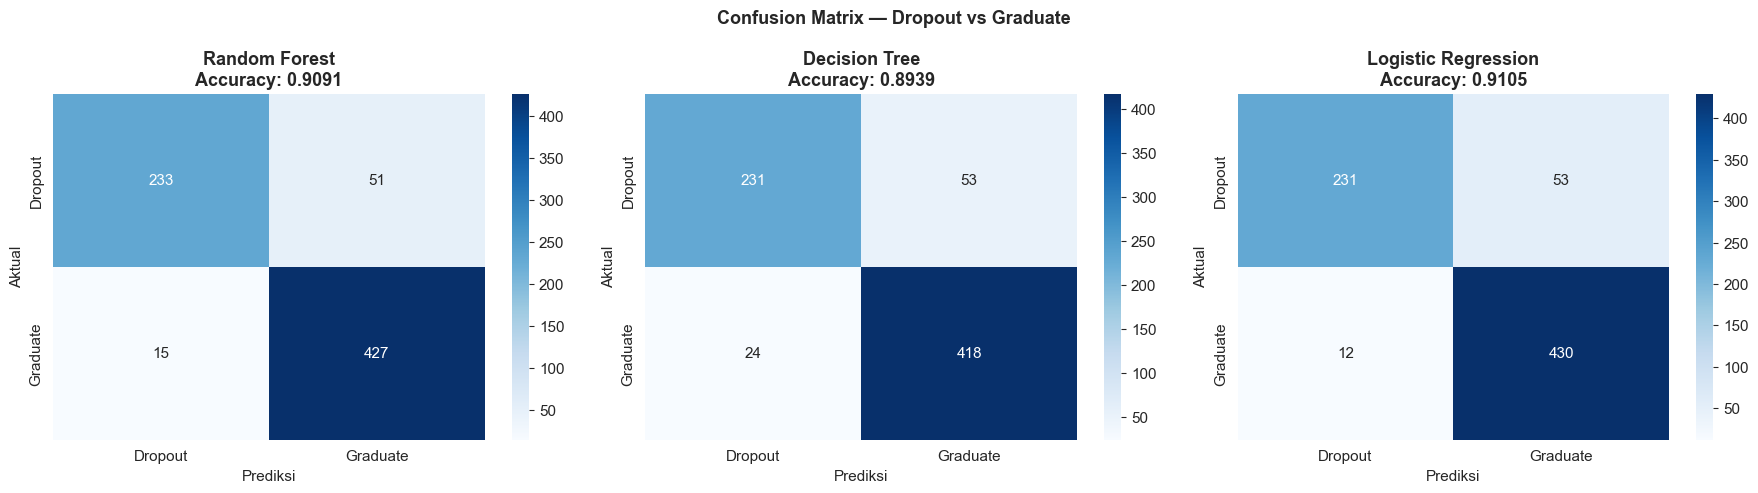

In [127]:
# Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, m) in zip(axes, models_eval.items()):
    pred = m.predict(X_test_scaled)
    cm   = confusion_matrix(y_test, pred)
    acc  = accuracy_score(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le_target.classes_,
                yticklabels=le_target.classes_, ax=ax)
    ax.set_title(f'{name}\nAccuracy: {acc:.4f}', fontweight='bold')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.suptitle('Confusion Matrix — Dropout vs Graduate',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

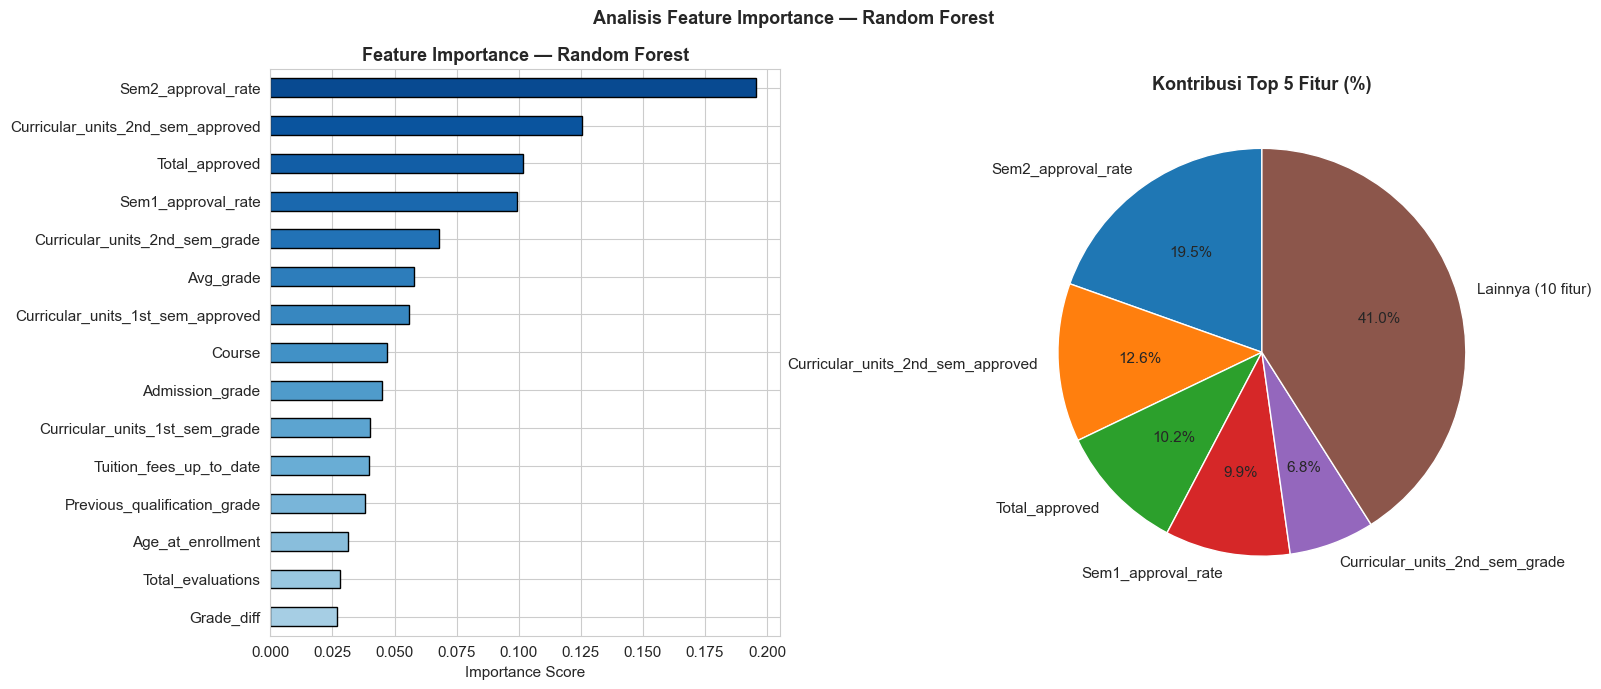

Top 5 fitur paling berpengaruh:
  1. Sem2_approval_rate                                 0.1955
  2. Curricular_units_2nd_sem_approved                  0.1256
  3. Total_approved                                     0.1019
  4. Sem1_approval_rate                                 0.0992
  5. Curricular_units_2nd_sem_grade                     0.0677


In [128]:
# Feature Importance
feat_final = pd.DataFrame({
    'Feature':    selected_features,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors_fi = plt.cm.Blues(np.linspace(0.35, 0.9, len(feat_final)))
feat_final.sort_values('Importance').plot(
    kind='barh', x='Feature', y='Importance',
    ax=axes[0], color=colors_fi, edgecolor='black', legend=False
)
axes[0].set_title('Feature Importance — Random Forest', fontweight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].set_ylabel('')

top5   = feat_final.head(5)
others = pd.DataFrame({'Feature':['Lainnya (10 fitur)'],
                        'Importance':[feat_final.tail(10)['Importance'].sum()]})
pie_df = pd.concat([top5, others])
axes[1].pie(pie_df['Importance'], labels=pie_df['Feature'],
            autopct='%1.1f%%', startangle=90,
            colors=plt.cm.tab10.colors[:6])
axes[1].set_title('Kontribusi Top 5 Fitur (%)', fontweight='bold')

plt.suptitle('Analisis Feature Importance — Random Forest',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 5 fitur paling berpengaruh:')
for i, (_, row) in enumerate(feat_final.head(5).iterrows(), 1):
    print(f'  {i}. {row["Feature"]:<50} {row["Importance"]:.4f}')

**Insight Evaluasi:**
- **Random Forest** menjadi model terbaik berdasarkan accuracy di test set.
- Klasifikasi **Dropout vs Graduate** (biner) menghasilkan performa lebih baik dibanding 3 kelas.
- Fitur `Sem2_approval_rate`, `Total_approved`, dan `Avg_grade` mendominasi feature importance.
- Confusion matrix menunjukkan model cukup baik mendeteksi kedua kelas.

## Menyimpan Model

In [129]:
os.makedirs('model', exist_ok=True)
joblib.dump(best_rf,           'model/model.joblib')
joblib.dump(scaler,            'model/scaler.joblib')
joblib.dump(le_target,         'model/label_encoder.joblib')
joblib.dump(selected_features, 'model/feature_names.joblib')

print('Model dan artifacts berhasil disimpan:')
for f in sorted(os.listdir('model')):
    print(f'   model/{f}')

verify = accuracy_score(y_test,
    joblib.load('model/model.joblib').predict(
        scaler.transform(X_test)))
print(f'\nVerifikasi akurasi model tersimpan: {verify:.4f}')
print(f'Kelas yang diprediksi: {list(le_target.classes_)}')

Model dan artifacts berhasil disimpan:
   model/.DS_Store
   model/feature_names.joblib
   model/label_encoder.joblib
   model/model.joblib
   model/scaler.joblib

Verifikasi akurasi model tersimpan: 0.9091
Kelas yang diprediksi: ['Dropout', 'Graduate']


## Kesimpulan

### 1. Faktor-faktor Penyebab Dropout (Berdasarkan EDA & Dashboard)

Berdasarkan hasil analisis data dan visualisasi dashboard:

| # | Faktor | Temuan |
|---|--------|--------|
| 1 | **Nilai Semester 1 & 2** | Siswa dropout memiliki nilai rata-rata jauh lebih rendah |
| 2 | **Mata Kuliah Lulus** | Siswa dropout lulus sangat sedikit MK di kedua semester |
| 3 | **Status SPP** | Siswa yang menunggak SPP memiliki dropout rate jauh lebih tinggi |
| 4 | **Status Beasiswa** | Penerima beasiswa memiliki dropout rate lebih rendah |
| 5 | **Usia Pendaftaran** | Siswa yang mendaftar di usia lebih tua lebih berisiko dropout |
| 6 | **Status Hutang** | Siswa dengan hutang memiliki risiko dropout lebih tinggi |

### 2. Performa Model Machine Learning

Model dilatih menggunakan data **Dropout vs Graduate** (biner), dengan fitur terpilih dari top 15 feature importance Random Forest.

> Hasil metrik performa (Accuracy, Precision, Recall, F1-Score) dapat dilihat pada output cell Evaluation di atas.

### Rekomendasi Action Items

1. **Bimbingan Akademik Dini** — Siswa dengan nilai Sem 1 rendah segera diberi pendampingan intensif
2. **Fleksibilitas Pembayaran SPP** — Skema cicilan bagi siswa kesulitan keuangan
3. **Perluasan Beasiswa** — Terbukti menurunkan dropout rate secara signifikan
4. **Early Warning System** — Monitoring bulanan; prob dropout ≥ 60% → bimbingan khusus
5. **Program Mentoring** — Khusus mahasiswa baru terutama usia lebih tua